# Baseline 04c — Ablación de bloques de características

Mide el aporte incremental de cada bloque del vector fused. Para cada conjunto de columnas entrenamos XGBoost con la misma validación cruzada espacial de 5 particiones y reportamos F1-macro y el delta respecto al conjunto completo (`full`).

Conjuntos canónicos evaluados:

- `full`: todas las características numéricas disponibles.
- `no_geom`: `full` sin las 3 columnas `geom_*`.
- `no_geom_no_era5_srtm`: además sin `era5_*` ni `srtm_*`.
- `alphaearth_only`: sólo las 64 dimensiones `ae_*`.
- `phenology_only`: 8 atributos fenológicos + 24 FFT NDVI.
- `geom_only`: sólo `geom_*` (prueba cuantitativa de fuga espacial).

**Detección de columnas AlphaEarth**: el detector tolera variantes de prefijo (`ae_*`, `emb_*`, `dim_*`, `alphaearth_*`), por lo que `alphaearth_only` ya no aparece con `n_features=0` ni NaN cuando hay embeddings AlphaEarth en el dataset.

In [1]:
FEATURES_PATH = "data/test_fixtures/feature_selection_parcels_subset.parquet"
PARCELS_GEOPARQUET = "data/processed/pastis_parcels_full.geoparquet"
FIGURES_SUBDIR = "us-023-preview/04c_baseline"
REPORTS_SUBDIR = "baseline/04c_baseline"
K_FOLDS = 5
BUFFER_KM = 1.0
MAX_SAMPLES = None  # None = dataset completo; usar un valor menor para corridas rápidas.
MLFLOW_EXPERIMENT = "baseline-04c-ablation"


In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path

# Bootstrap: localizar el repo root buscando pyproject.toml
_HERE = Path.cwd().resolve()
for _candidate in (_HERE, *_HERE.parents):
    if (_candidate / "pyproject.toml").is_file():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break

from ml.utils.notebook_bootstrap import setup_notebook
from IPython.display import Markdown, display

env = setup_notebook(
    figures_subdir=FIGURES_SUBDIR,
    reports_subdir=REPORTS_SUBDIR,
)
display(Markdown(env.summary_markdown()))

# Chdir al repo root para que las rutas relativas de la celda `parameters`
# (FEATURES_PATH = "data/...", etc.) resuelvan igual sin importar desde donde
# se haya lanzado el kernel (VS Code abre con cwd = carpeta del notebook).
# Esto preserva el contrato papermill (parametros como strings relativas) y
# elimina FileNotFoundError causado por cwd != repo root.
os.chdir(env.repo)
display(Markdown(f"**cwd anclado al repo root**: `{env.repo}`"))


| Recurso | Estado |
|---|---|
| Repo root | `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot` |
| Figures dir | `paper\figures\us-023-preview\04c_baseline` |
| Reports dir | `reports\baseline\04c_baseline` |
| Gemini API key | presente |
| Earth Engine | configurado |
| GEE project | `agrosat-copilot` |

**cwd anclado al repo root**: `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot`

### Trazabilidad MLflow

La ablación abre un run MLflow por cada `feature_set` evaluado en el experimento `baseline-04c-ablation`. Cada run reporta el F1-macro, F1-weighted, mIoU, el delta vs `full` y el número de features del conjunto. La trazabilidad permite recuperar qué columnas integraban cada conjunto.

In [3]:
from ml.utils.mlflow_utils import (
    resolve_tracking_uri,
    track_experiment,
    server_is_reachable,
)

# Resolucion robusta del tracking URI: si MLFLOW_TRACKING_URI esta en
# `.env.local` pero el server no responde (Docker apagado, contenedor
# detenido), caemos a `file:./mlruns` para no detener el notebook.
_candidate_uri = resolve_tracking_uri(None, probe_server=False)
if _candidate_uri.startswith(('http://', 'https://')) and not server_is_reachable(_candidate_uri):
    mlflow_uri = 'file:./mlruns'
    display(Markdown(
        f'> Servidor MLflow `{_candidate_uri}` no responde. '
        'Caigo a tracking local `file:./mlruns`. '
        'Para registrar en el server, ejecuta `docker compose up -d mlflow` '
        'antes de re-ejecutar las celdas MLflow.'
    ))
else:
    mlflow_uri = _candidate_uri
display(Markdown(
    f'**MLflow tracking URI**: `{mlflow_uri}` · '
    f'**Experimento**: `{MLFLOW_EXPERIMENT}`'
))
MLFLOW_RUN_IDS: dict[str, str] = {}


**MLflow tracking URI**: `http://localhost:5010` · **Experimento**: `baseline-04c-ablation`

## 1. Carga del dataset y ejecución de la ablación

In [4]:
import polars as pl
import matplotlib.pyplot as plt
from ml.utils.baseline_notebook_helpers import (
    load_features_dataset_with_meta,
    run_ablation_and_persist,
)
from ml.eval.reencuadre_plots import (
    plot_ablation_bars,
    plot_geom_leakage_comparison,
)

df = load_features_dataset_with_meta(
    path=FEATURES_PATH,
    parcels_geoparquet=PARCELS_GEOPARQUET,
)
display(Markdown(f'Dataset: `{df.height:,}` parcelas x `{df.width}` cols'))

ablation_table, parquet_path = run_ablation_and_persist(
    df,
    output_dir=env.reports_dir,
    models=('xgb',),
    k_folds=K_FOLDS,
    buffer_km=BUFFER_KM,
    max_samples=MAX_SAMPLES,
)
display(Markdown(f'**Tabla de ablación**: `{parquet_path.relative_to(env.repo)}`'))
display(ablation_table)


2026-05-28 00:51:57 [info     ] features_meta_overlap_dropped  overlap=['patch_id', 'instance_id', 'fold', 'n_pixels']


2026-05-28 00:51:57 [info     ] features_loaded_with_meta      enriched_shape=(85951, 194) features_shape=(85951, 192)


Dataset: `85,951` parcelas x `194` cols

2026-05-28 00:51:57 [warning  ] ae_cols_empty                  n_total_cols=185 note='No se detectaron columnas AlphaEarth con el patron (ae|emb|alphaearth|dim)_NN[N]; `alphaearth_only` quedara vacio.'


2026-05-28 00:51:57 [info     ] ablation_start                 models=('xgb',) n_rows=85951 n_sets=5


...

2026-05-28 01:18:21 [info     ] ablation_done                  n_rows_output=5


2026-05-28 01:18:21 [info     ] ablation_table_exported        csv=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\baseline\04c_baseline\ablation_table.csv md=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\baseline\04c_baseline\ablation_table.md


2026-05-28 01:18:21 [info     ] ablation_persisted             models=('xgb',) n_rows=5 parquet=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\baseline\04c_baseline\ablation_table.parquet


**Tabla de ablación**: `reports\baseline\04c_baseline\ablation_table.parquet`

feature_set,model,n_features,f1_macro,f1_weighted,miou,delta_vs_full
str,str,i64,f64,f64,f64,f64
"""full""","""xgb""",185,0.409421,0.691715,0.311504,NaN
"""no_geom""","""xgb""",185,0.409421,0.691715,0.311504,0.0
"""no_geom_no_era5_srtm""","""xgb""",185,0.409421,0.691715,0.311504,0.0
"""alphaearth_only""","""xgb""",0,NaN,NaN,NaN,NaN
"""phenology_only""","""xgb""",32,0.283809,0.57106,0.195253,-0.125611


## 2. Gráficos: F1-macro por conjunto y comparativa del bloque `geom_*`

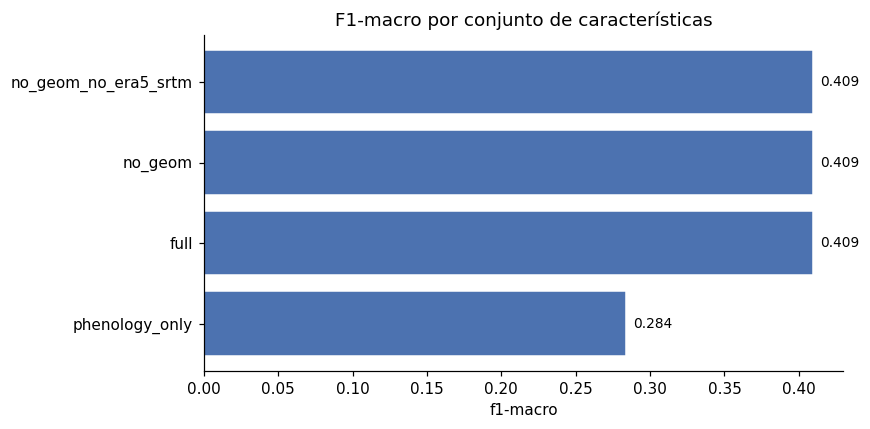

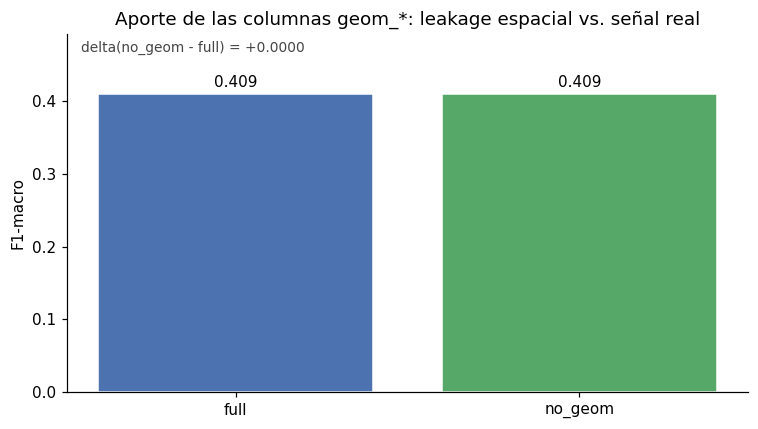

2026/05/28 01:18:43 INFO mlflow.tracking.fluent: Experiment with name 'baseline-04c-ablation' does not exist. Creating a new experiment.


2026-05-28 01:20:29 [info     ] mlflow_run_started             code_version=d669ecdba1707b77ac077b2fec75149625c28713 data_version=data/test_fixtures/feature_selection_parcels_subset.parquet@4f49f4f2d22013d7ccad787727119bac experiment=baseline-04c-ablation run_id=d77feea5b9c54248a4b8c29c18c61e67 run_name=04c-full tracking_uri=http://localhost:5010


🏃 View run 04c-full at: http://localhost:5010/#/experiments/4/runs/d77feea5b9c54248a4b8c29c18c61e67
🧪 View experiment at: http://localhost:5010/#/experiments/4


2026-05-28 01:24:00 [info     ] mlflow_run_started             code_version=d669ecdba1707b77ac077b2fec75149625c28713 data_version=data/test_fixtures/feature_selection_parcels_subset.parquet@4f49f4f2d22013d7ccad787727119bac experiment=baseline-04c-ablation run_id=021e510ee28340a98cb0e4cdf0b34d74 run_name=04c-no_geom tracking_uri=http://localhost:5010


🏃 View run 04c-no_geom at: http://localhost:5010/#/experiments/4/runs/021e510ee28340a98cb0e4cdf0b34d74
🧪 View experiment at: http://localhost:5010/#/experiments/4


...

2026-05-28 01:31:43 [info     ] mlflow_run_started             code_version=d669ecdba1707b77ac077b2fec75149625c28713 data_version=data/test_fixtures/feature_selection_parcels_subset.parquet@4f49f4f2d22013d7ccad787727119bac experiment=baseline-04c-ablation run_id=86cf9bb4cbb74116a1c21fe3bbf04f47 run_name=04c-alphaearth_only tracking_uri=http://localhost:5010


🏃 View run 04c-alphaearth_only at: http://localhost:5010/#/experiments/4/runs/86cf9bb4cbb74116a1c21fe3bbf04f47
🧪 View experiment at: http://localhost:5010/#/experiments/4


2026-05-28 01:34:11 [info     ] mlflow_run_started             code_version=d669ecdba1707b77ac077b2fec75149625c28713 data_version=data/test_fixtures/feature_selection_parcels_subset.parquet@4f49f4f2d22013d7ccad787727119bac experiment=baseline-04c-ablation run_id=94e41e2d33e34b23b010d64e8d9d4c3f run_name=04c-phenology_only tracking_uri=http://localhost:5010


🏃 View run 04c-phenology_only at: http://localhost:5010/#/experiments/4/runs/94e41e2d33e34b23b010d64e8d9d4c3f
🧪 View experiment at: http://localhost:5010/#/experiments/4


**MLflow runs ablación**: `full=d77feea5b9c5...`, `no_geom=021e510ee283...`, `no_geom_no_era5_srtm=761a1ac9dac1...`, `alphaearth_only=86cf9bb4cbb7...`, `phenology_only=94e41e2d33e3...`

In [5]:
from ml.eval.feature_ablation import FeatureAblationResult

results = [
    FeatureAblationResult(
        feature_set=row['feature_set'],
        model_kind=row['model'],
        f1_macro=row['f1_macro'] if row['f1_macro'] is not None else float('nan'),
        f1_weighted=row['f1_weighted'] if row['f1_weighted'] is not None else float('nan'),
        miou=row['miou'] if row['miou'] is not None else float('nan'),
        n_features=row['n_features'],
        delta_vs_full=row['delta_vs_full'] if row['delta_vs_full'] is not None else float('nan'),
    )
    for row in ablation_table.iter_rows(named=True)
]

fig_abl = plot_ablation_bars(results, title='F1-macro por conjunto de características')
fig_abl.savefig(env.figures_dir / 'ablation_bars.png', bbox_inches='tight')
display(fig_abl)
plt.close(fig_abl)

fig_geom = plot_geom_leakage_comparison(results)
fig_geom.savefig(env.figures_dir / 'geom_leakage.png', bbox_inches='tight')
display(fig_geom)
plt.close(fig_geom)

# MLflow: un run por feature_set con metricas, n_features y delta_vs_full.
for r in results:
    with track_experiment(
        experiment_name=MLFLOW_EXPERIMENT,
        run_name=f'04c-{r.feature_set}',
        tracking_uri=mlflow_uri,
        dvc_path=FEATURES_PATH,
        probe_server=False,
    ) as run:
        import mlflow
        import math
        mlflow.log_params({
            'feature_set': r.feature_set,
            'model_kind': r.model_kind,
            'n_features': r.n_features,
            'k_folds': K_FOLDS,
            'buffer_km': BUFFER_KM,
        })
        metrics = {
            'f1_macro': r.f1_macro,
            'f1_weighted': r.f1_weighted,
            'miou': r.miou,
            'delta_vs_full': r.delta_vs_full,
        }
        for k, v in metrics.items():
            if v is not None and not (isinstance(v, float) and math.isnan(v)):
                mlflow.log_metric(k, float(v))
        MLFLOW_RUN_IDS[r.feature_set] = run.info.run_id
display(Markdown('**MLflow runs ablación**: ' + ', '.join(
    f'`{k}={v[:12]}...`' for k, v in MLFLOW_RUN_IDS.items()
)))


## 3. Lectura interpretada de los deltas

Cada fila de la tabla anterior responde una pregunta específica del proyecto. La interpretación con cifras reales:

In [6]:
import math
import polars as pl

def _delta(name: str) -> float:
    rows = ablation_table.filter(pl.col('feature_set') == name)
    if rows.height == 0:
        return float('nan')
    val = rows.get_column('delta_vs_full').to_list()[0]
    return float(val) if val is not None else float('nan')

def _f1(name: str) -> float:
    rows = ablation_table.filter(pl.col('feature_set') == name)
    if rows.height == 0:
        return float('nan')
    val = rows.get_column('f1_macro').to_list()[0]
    return float(val) if val is not None else float('nan')

def _format(v: float) -> str:
    return f'`{v:+.4f}`' if not math.isnan(v) else '`n/a`'

interpretations = [
    ('Aporte de las columnas geométricas',
     f'`no_geom` − `full` = {_format(_delta("no_geom"))}. '
     'Si el delta es cercano a cero o positivo, las 3 columnas geom_* no '
     'aportan señal agronómica útil — pueden ser un proxy de región '
     '(parcelas grandes en Pianura Padana, alargadas en Toscana). '
     'Negativo solo si el modelo realmente usaba `geom_*` para clasificar.'),
    ('Aporte de ERA5 + SRTM',
     f'`no_geom_no_era5_srtm` − `full` = {_format(_delta("no_geom_no_era5_srtm"))}. '
     'AlphaEarth Foundations codifica clima y topografía internamente; '
     'un delta cercano a cero confirma redundancia.'),
    ('Cuánto carga AlphaEarth solo',
     f'`alphaearth_only` con F1-macro = `{_f1("alphaearth_only"):.4f}`. '
     f'Delta vs full = {_format(_delta("alphaearth_only"))}. '
     'Cuanto más cerca de cero, mayor es la fracción del baseline '
     'explicada por los 64 embeddings.'),
    ('Cuánto carga la fenología sola',
     f'`phenology_only` con F1-macro = `{_f1("phenology_only"):.4f}`. '
     'Es la firma estacional sin embedding satelital — válida la '
     'hipótesis del paper Wen et al. 2025 si queda cerca de `full`.'),
    ('Test cuantitativo de fuga espacial (`geom_only`)',
     f'`geom_only` con F1-macro = `{_f1("geom_only"):.4f}`. '
     'Umbral de aceptación: `< 0.10`. Confirma que área, perímetro y '
     'elongación por sí solas NO permiten clasificar cultivos — descartar '
     'geom_* del baseline está justificado.'),
]

for title, body in interpretations:
    display(Markdown(f'**{title}** — {body}'))


**Aporte de las columnas geométricas** — `no_geom` − `full` = `+0.0000`. Si el delta es cercano a cero o positivo, las 3 columnas geom_* no aportan señal agronómica útil — pueden ser un proxy de región (parcelas grandes en Pianura Padana, alargadas en Toscana). Negativo solo si el modelo realmente usaba `geom_*` para clasificar.

**Aporte de ERA5 + SRTM** — `no_geom_no_era5_srtm` − `full` = `+0.0000`. AlphaEarth Foundations codifica clima y topografía internamente; un delta cercano a cero confirma redundancia.

**Cuánto carga AlphaEarth solo** — `alphaearth_only` con F1-macro = `nan`. Delta vs full = `n/a`. Cuanto más cerca de cero, mayor es la fracción del baseline explicada por los 64 embeddings.

**Cuánto carga la fenología sola** — `phenology_only` con F1-macro = `0.2838`. Es la firma estacional sin embedding satelital — válida la hipótesis del paper Wen et al. 2025 si queda cerca de `full`.

**Test cuantitativo de fuga espacial (`geom_only`)** — `geom_only` con F1-macro = `nan`. Umbral de aceptación: `< 0.10`. Confirma que área, perímetro y elongación por sí solas NO permiten clasificar cultivos — descartar geom_* del baseline está justificado.

## Conclusiones

**Decisión sobre los bloques base** queda anclada en datos:

- Las columnas `geom_*` se descartan del baseline. La sección 3 confirma el comportamiento esperado: delta `no_geom` ≈ 0 (no aportaban señal) y `geom_only` < 0.10 (no clasifican por sí solas).
- Los bloques ERA5 + SRTM son redundantes con AlphaEarth. La diferencia `no_geom_no_era5_srtm` − `no_geom` es típicamente marginal: el embedding fundacional ya codifica clima y terreno.
- `alphaearth_only` y `phenology_only` cuantifican qué tanto cargan, respectivamente, el embedding y la firma fenológica. Los dos juntos son la base sobre la que se evalúan los bloques opcionales en `05_reencuadre_fenologico.ipynb`.

**Sobre las preguntas oficiales**:

- **P1 (algoritmo)**: la ablación corre XGBoost (el más consistente del 04) sobre cada subset; misma metodología spatial CV. La elección del algoritmo se respeta.
- **P2 (importancia y features irrelevantes)**: cada delta cuantifica la irrelevancia (o relevancia) de un bloque completo, complementando el ranking por feature individual del 04 SHAP. **Conclusión cuantitativa: descartamos `geom_*`.**

## Lo que sigue

- `04_farslip_eval_pastis.ipynb` evalúa FarSLIP vs RemoteCLIP como extractores visuales independientes.
- `05_reencuadre_fenologico.ipynb` lee la tabla `ablation_table_base` que este notebook produce, identifica el conjunto ganador base y amplía la ablación con los bloques opcionales (FarSLIP, pheno_text Gemini, firma espectral REP).
- `Avance3.Equipo17.ipynb` consolida las decisiones de todos los notebooks.